In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.tree import plot_tree, export_text
from sklearn.naive_bayes import GaussianNB


In [2]:
df = pd.read_parquet(Path(r"E:\ProyectoAnalisisElectrico\Cmg\TrainMacrozona.parquet"))

In [3]:
df = df.drop(columns=["tension", "nombre_barra", "CMg[CLP/KWh]", "Periodo", "CMg[CLP/KWh]_mes", "CMg[CLP/KWh]_period", "Año"], errors = "ignore")

In [4]:
df.columns=["name", "hora", "cmg", "mes", "cmg_mes", "cmg_period", "macrozona"]

In [5]:
df_ordenado = df.sort_values(['name', 'mes', 'hora'])
df_ordenado['Rampa'] = df_ordenado.groupby('name')['cmg'].diff()

df_rampas = df_ordenado.groupby('name').agg(
    rampa_max_subida=('Rampa', 'max'),
    rampa_max_bajada=('Rampa', 'min')
).reset_index()

df_24h = df.groupby(["name", "hora"])["cmg"].mean().reset_index()
df_24h_pivot = df_24h.pivot(index="name", columns="hora", values="cmg").reset_index()
df_24h_pivot.columns = ["name"] + [f"hora_{int(h)}" for h in df_24h_pivot.columns[1:]]

df_mes = df.groupby(["name", "mes"])["cmg"].mean().reset_index()
df_mes_pivot = df_mes.pivot(index="name", columns="mes", values="cmg").reset_index()
df_mes_pivot.columns = ["name"] + [f"mes_{int(m)}" for m in df_mes_pivot.columns[1:]]

df_base = df[['name', 'macrozona']].drop_duplicates()

dff = pd.merge(df_base, df_rampas, on="name")
dff = pd.merge(dff, df_24h_pivot, on="name")
dff = pd.merge(dff, df_mes_pivot, on="name")

print(dff.head())


                name     macrozona  rampa_max_subida  rampa_max_bajada  \
0  A_____________100  Norte Grande         74.936885        -75.577014   
1  A.BLANCAS_____013    Centro Sur         65.965487        -58.319837   
2  A.BLANCAS_____066    Centro Sur         65.631527        -58.186356   
3  A.DERIBERA____066    Centro Sur         64.669454        -57.671475   
4  A.DERIBERA____154    Centro Sur         64.055956        -57.518794   

      hora_1     hora_2     hora_3     hora_4     hora_5     hora_6  ...  \
0  69.960049  69.502326  70.304445  70.677094  70.318435  72.261852  ...   
1  71.838979  68.897581  67.056105  65.430877  65.510684  68.252664  ...   
2  71.569747  68.669095  66.850607  65.242480  65.324337  68.053178  ...   
3  70.548017  67.564209  65.703331  64.099079  64.155464  66.882941  ...   
4  70.084010  67.252102  65.476083  63.913948  63.986469  66.698134  ...   

       mes_3      mes_4      mes_5       mes_6      mes_7      mes_8  \
0  33.877745  38.317423  5

In [ ]:

X = dff.drop(columns=['name', 'macrozona'])
y = dff['macrozona']

le = LabelEncoder()
y_num = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_num, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_num
)

def procesar_features(df_in, valor_referencia=None):
    df_out = df_in.copy()
    cols_horas = [f"hora_{i}" for i in range(1, 25)]
    cols_meses = [f"mes_{i}" for i in range(1, 13)]
    cols_rampas = ['rampa_max_subida', 'rampa_max_bajada']
    max_por_barra = df_out[cols_horas].max(axis=1).replace(0, 1)
    if valor_referencia is None:
        valor_referencia = max_por_barra.median()

    df_out['factor_magnitud'] = max_por_barra / valor_referencia
    for col in cols_horas + cols_meses + cols_rampas:
        df_out[col] = df_out[col] / max_por_barra
        
    return df_out.fillna(-1), valor_referencia

X_train_norm, ref_sistema = procesar_features(X_train)
X_val_norm, _ = procesar_features(X_val, valor_referencia=ref_sistema)


In [29]:
X_train_norm.head()

,rampa_max_subida,rampa_max_bajada,hora_1,hora_2,hora_3,hora_4,hora_5,hora_6,hora_7,hora_8,...,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
224,0.856640,-0.748645,0.851176,0.814060,0.788913,0.769093,0.773311,0.808921,0.889975,0.753541,...,0.545928,0.581420,0.781089,1.429083,1.234743,0.535322,0.462236,0.338634,0.621183,0.515779
494,0.797843,-0.746484,0.881954,0.850246,0.830058,0.811097,0.812576,0.848906,0.921396,0.761945,...,0.512169,0.546220,0.742329,1.323587,1.063819,0.558901,0.499541,0.414232,0.591905,0.485783
735,0.667636,-0.745918,0.777251,0.729818,0.697434,0.677795,0.677542,0.706653,0.771481,0.654219,...,0.479248,0.464246,0.721513,1.531931,1.028317,0.493337,0.429437,0.338343,0.497969,0.429584
535,1.051342,-1.024213,0.908790,0.892552,0.887226,0.889672,0.896228,0.928287,0.992426,0.780167,...,0.438103,0.498359,0.725901,0.845293,0.833616,0.498649,0.482576,0.447139,0.567411,0.502033
395,0.694739,-0.578885,0.741403,0.698255,0.669959,0.645445,0.641653,0.669223,0.727219,0.615122,...,0.419323,0.451669,0.643919,1.162220,0.925377,0.505996,0.405780,0.318298,0.488756,0.406985


In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train_norm, y_train)
precision_train = rf_model.score(X_train_norm, y_train)
precision = rf_model.score(X_val_norm, y_val)
print(f"Precisión inicial del modelo: {precision * 100:.2f}%\n", precision_train)

Precisión inicial del modelo: 95.48%
 0.9632248939179632


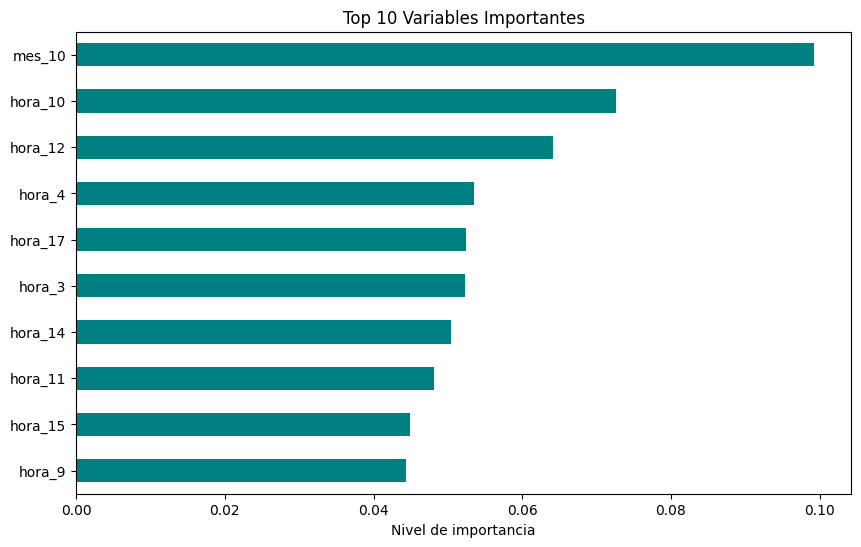

In [18]:
importancias = pd.Series(rf_model.feature_importances_, index=X_train_norm.columns)
importancias.nlargest(10).sort_values().plot(kind='barh', color='teal', figsize=(10, 6))
plt.title("Top 10 Variables Importantes")
plt.xlabel("Nivel de importancia")
plt.show()

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Centro       0.96      0.98      0.97        50
  Centro Sur       0.98      0.96      0.97        53
 Norte Chico       0.91      1.00      0.95        20
Norte Grande       1.00      0.96      0.98        27
         Sur       0.96      0.93      0.94        27

    accuracy                           0.97       177
   macro avg       0.96      0.97      0.96       177
weighted avg       0.97      0.97      0.97       177



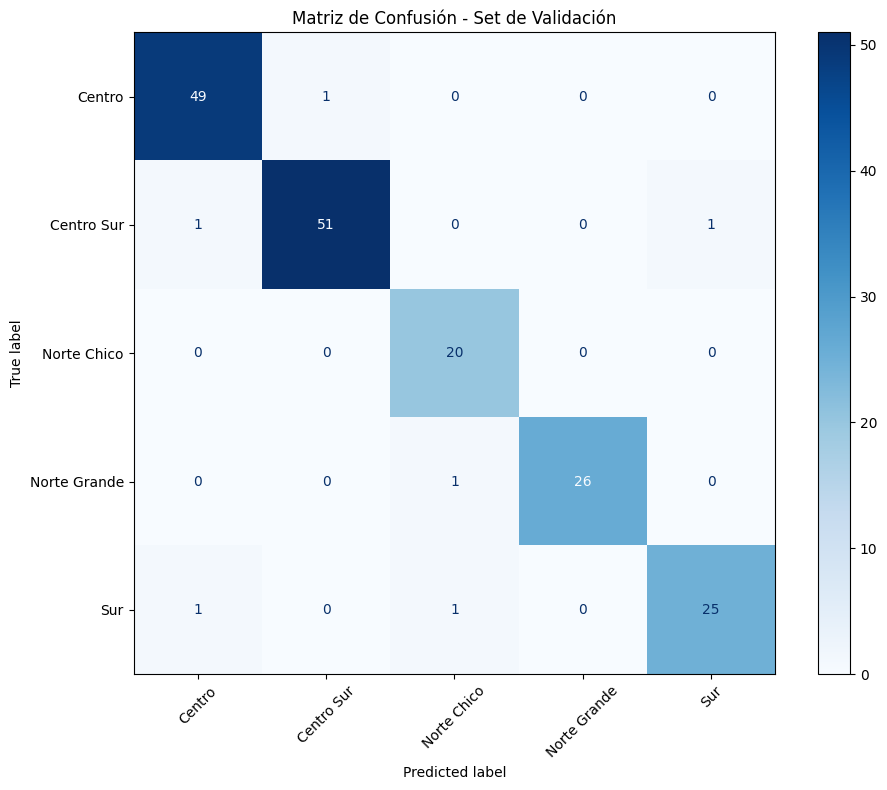

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = rf_model.predict(X_val_norm)

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_val, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión - Set de Validación")
plt.tight_layout()
plt.show()

In [10]:
df_testing = pd.read_parquet(Path(r"E:\ProyectoAnalisisElectrico\Cmg\TestMacrozona.parquet"))

In [11]:
df_testing.head()

,nombre_barra,tension,nombre_barra_cmg,HORA,CMg[CLP/KWh],CMg[USD/MWh],Año,Mes,Periodo,CMg[CLP/KWh]_mes,CMg[USD/MWh]_mes,CMg[CLP/KWh]_period,CMg[USD/MWh]_period,Macrozona
216,A.JAHUEL,110,A.JAHUEL______110,1,64.826013,68.775147,2025,05,2505_2604,58.68862,62.293742,48.730017,52.375135,Centro
217,A.JAHUEL,110,A.JAHUEL______110,2,62.988808,66.829561,2025,05,2505_2604,58.68862,62.293742,48.730017,52.375135,Centro
218,A.JAHUEL,110,A.JAHUEL______110,3,61.891801,65.667358,2025,05,2505_2604,58.68862,62.293742,48.730017,52.375135,Centro
219,A.JAHUEL,110,A.JAHUEL______110,4,61.510820,65.280983,2025,05,2505_2604,58.68862,62.293742,48.730017,52.375135,Centro
220,A.JAHUEL,110,A.JAHUEL______110,5,62.487232,66.309687,2025,05,2505_2604,58.68862,62.293742,48.730017,52.375135,Centro


CONSIDERANDO EL VALOR DE MAGNITUD
--- REPORTE DE CLASIFICACIÓN (SET DE TEST - DATOS NUEVOS) ---
              precision    recall  f1-score   support

      Centro       0.97      0.97      0.97        63
  Centro Sur       0.97      0.97      0.97        66
 Norte Chico       1.00      1.00      1.00        25
Norte Grande       1.00      1.00      1.00        34
         Sur       1.00      1.00      1.00        34

    accuracy                           0.98       222
   macro avg       0.99      0.99      0.99       222
weighted avg       0.98      0.98      0.98       222



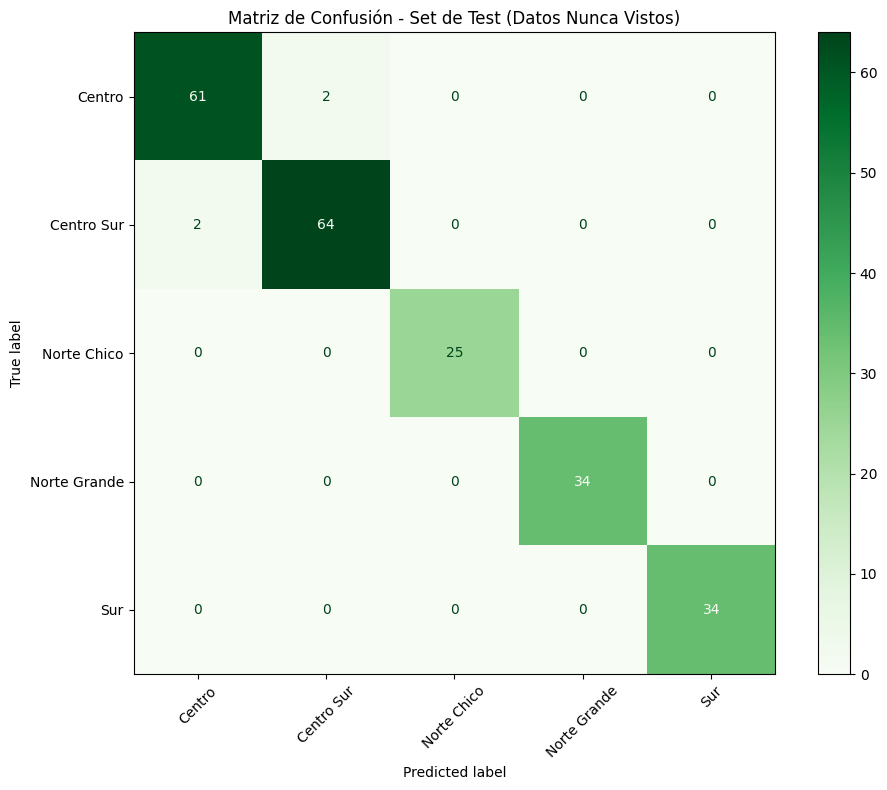

CONSIDERANDO EL VALOR DE MAGNITUD


In [19]:
# 1. RENOMBRAR Y LIMPIAR (Adaptamos los nombres crudos a los que usó nuestro script)
df_test_clean = pd.DataFrame()
df_test_clean['name'] = df_testing['nombre_barra_cmg']
df_test_clean['hora'] = pd.to_numeric(df_testing['HORA']).astype(int)
df_test_clean['cmg'] = pd.to_numeric(df_testing['CMg[USD/MWh]'])
df_test_clean['mes'] = pd.to_numeric(df_testing['Mes']).astype(int)
df_test_clean['macrozona'] = df_testing['Macrozona']  # Asumo que esta columna existe en tu test

# 2. COMPRESIÓN A FORMATO ANCHO (Crear las 38 variables)
# a) Rampas
df_test_ord = df_test_clean.sort_values(['name', 'mes', 'hora'])
df_test_ord['Rampa'] = df_test_ord.groupby('name')['cmg'].diff()
df_test_rampas = df_test_ord.groupby('name').agg(
    rampa_max_subida=('Rampa', 'max'),
    rampa_max_bajada=('Rampa', 'min')
).reset_index()

# b) Perfil 24 Horas
df_test_24h = df_test_clean.groupby(["name", "hora"])["cmg"].mean().reset_index()
df_test_24h_pivot = df_test_24h.pivot(index="name", columns="hora", values="cmg").reset_index()
df_test_24h_pivot.columns = ["name"] + [f"hora_{int(h)}" for h in df_test_24h_pivot.columns[1:]]

# c) Perfil 12 Meses
df_test_mes = df_test_clean.groupby(["name", "mes"])["cmg"].mean().reset_index()
df_test_mes_pivot = df_test_mes.pivot(index="name", columns="mes", values="cmg").reset_index()
df_test_mes_pivot.columns = ["name"] + [f"mes_{int(m)}" for m in df_test_mes_pivot.columns[1:]]

# d) Consolidar Matriz
df_test_base = df_test_clean[['name', 'macrozona']].drop_duplicates()
dff_test_wide = pd.merge(df_test_base, df_test_rampas, on="name")
dff_test_wide = pd.merge(dff_test_wide, df_test_24h_pivot, on="name")
dff_test_wide = pd.merge(dff_test_wide, df_test_mes_pivot, on="name")

# 3. PREPARACIÓN PARA EL MODELO
X_test_raw = dff_test_wide.drop(columns=['name', 'macrozona'])
y_test_raw = dff_test_wide['macrozona']

# TRUCO PRO: Reindexar. Esto garantiza que X_test tenga exactamente las mismas columnas 
# y en el mismo orden que X_train (por si el test set no tuviera datos para un mes específico)
X_test_raw = X_test_raw.reindex(columns=X_train.columns)

# 4. NORMALIZACIÓN Y TRANSFORMACIÓN
# Usamos la función procesar_features que definimos en el paso anterior
X_test_norm , _ = procesar_features(X_test_raw, ref_sistema)

# Transformamos el texto de las macrozonas a números usando el LabelEncoder ya entrenado
y_test_num = le.transform(y_test_raw)

# 5. PREDICCIÓN Y EXAMEN FINAL
y_pred_test = rf_model.predict(X_test_norm)
print("CONSIDERANDO EL VALOR DE MAGNITUD")
print("--- REPORTE DE CLASIFICACIÓN (SET DE TEST - DATOS NUEVOS) ---")
print(classification_report(y_test_num, y_pred_test, target_names=le.classes_))

# 6. GRÁFICO MATRIZ DE CONFUSIÓN
cm_test = confusion_matrix(y_test_num, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_test.plot(cmap='Greens', ax=ax, xticks_rotation=45) # Usamos verde para diferenciar de la validación
plt.title("Matriz de Confusión - Set de Test (Datos Nunca Vistos)")
plt.tight_layout()
plt.show()
print("CONSIDERANDO EL VALOR DE MAGNITUD")

In [20]:
joblib.dump(rf_model, Path(r'E:\ProyectoAnalisisElectrico\Modelos\ModeloSegmentacion\rf_model_energia_d5.joblib'))
joblib.dump(le, Path(r'E:\ProyectoAnalisisElectrico\Modelos\ModeloSegmentacion\label_encoder_energia_d5.joblib'))


['E:\\ProyectoAnalisisElectrico\\Modelos\\ModeloSegmentacion\\label_encoder_energia_d5.joblib']

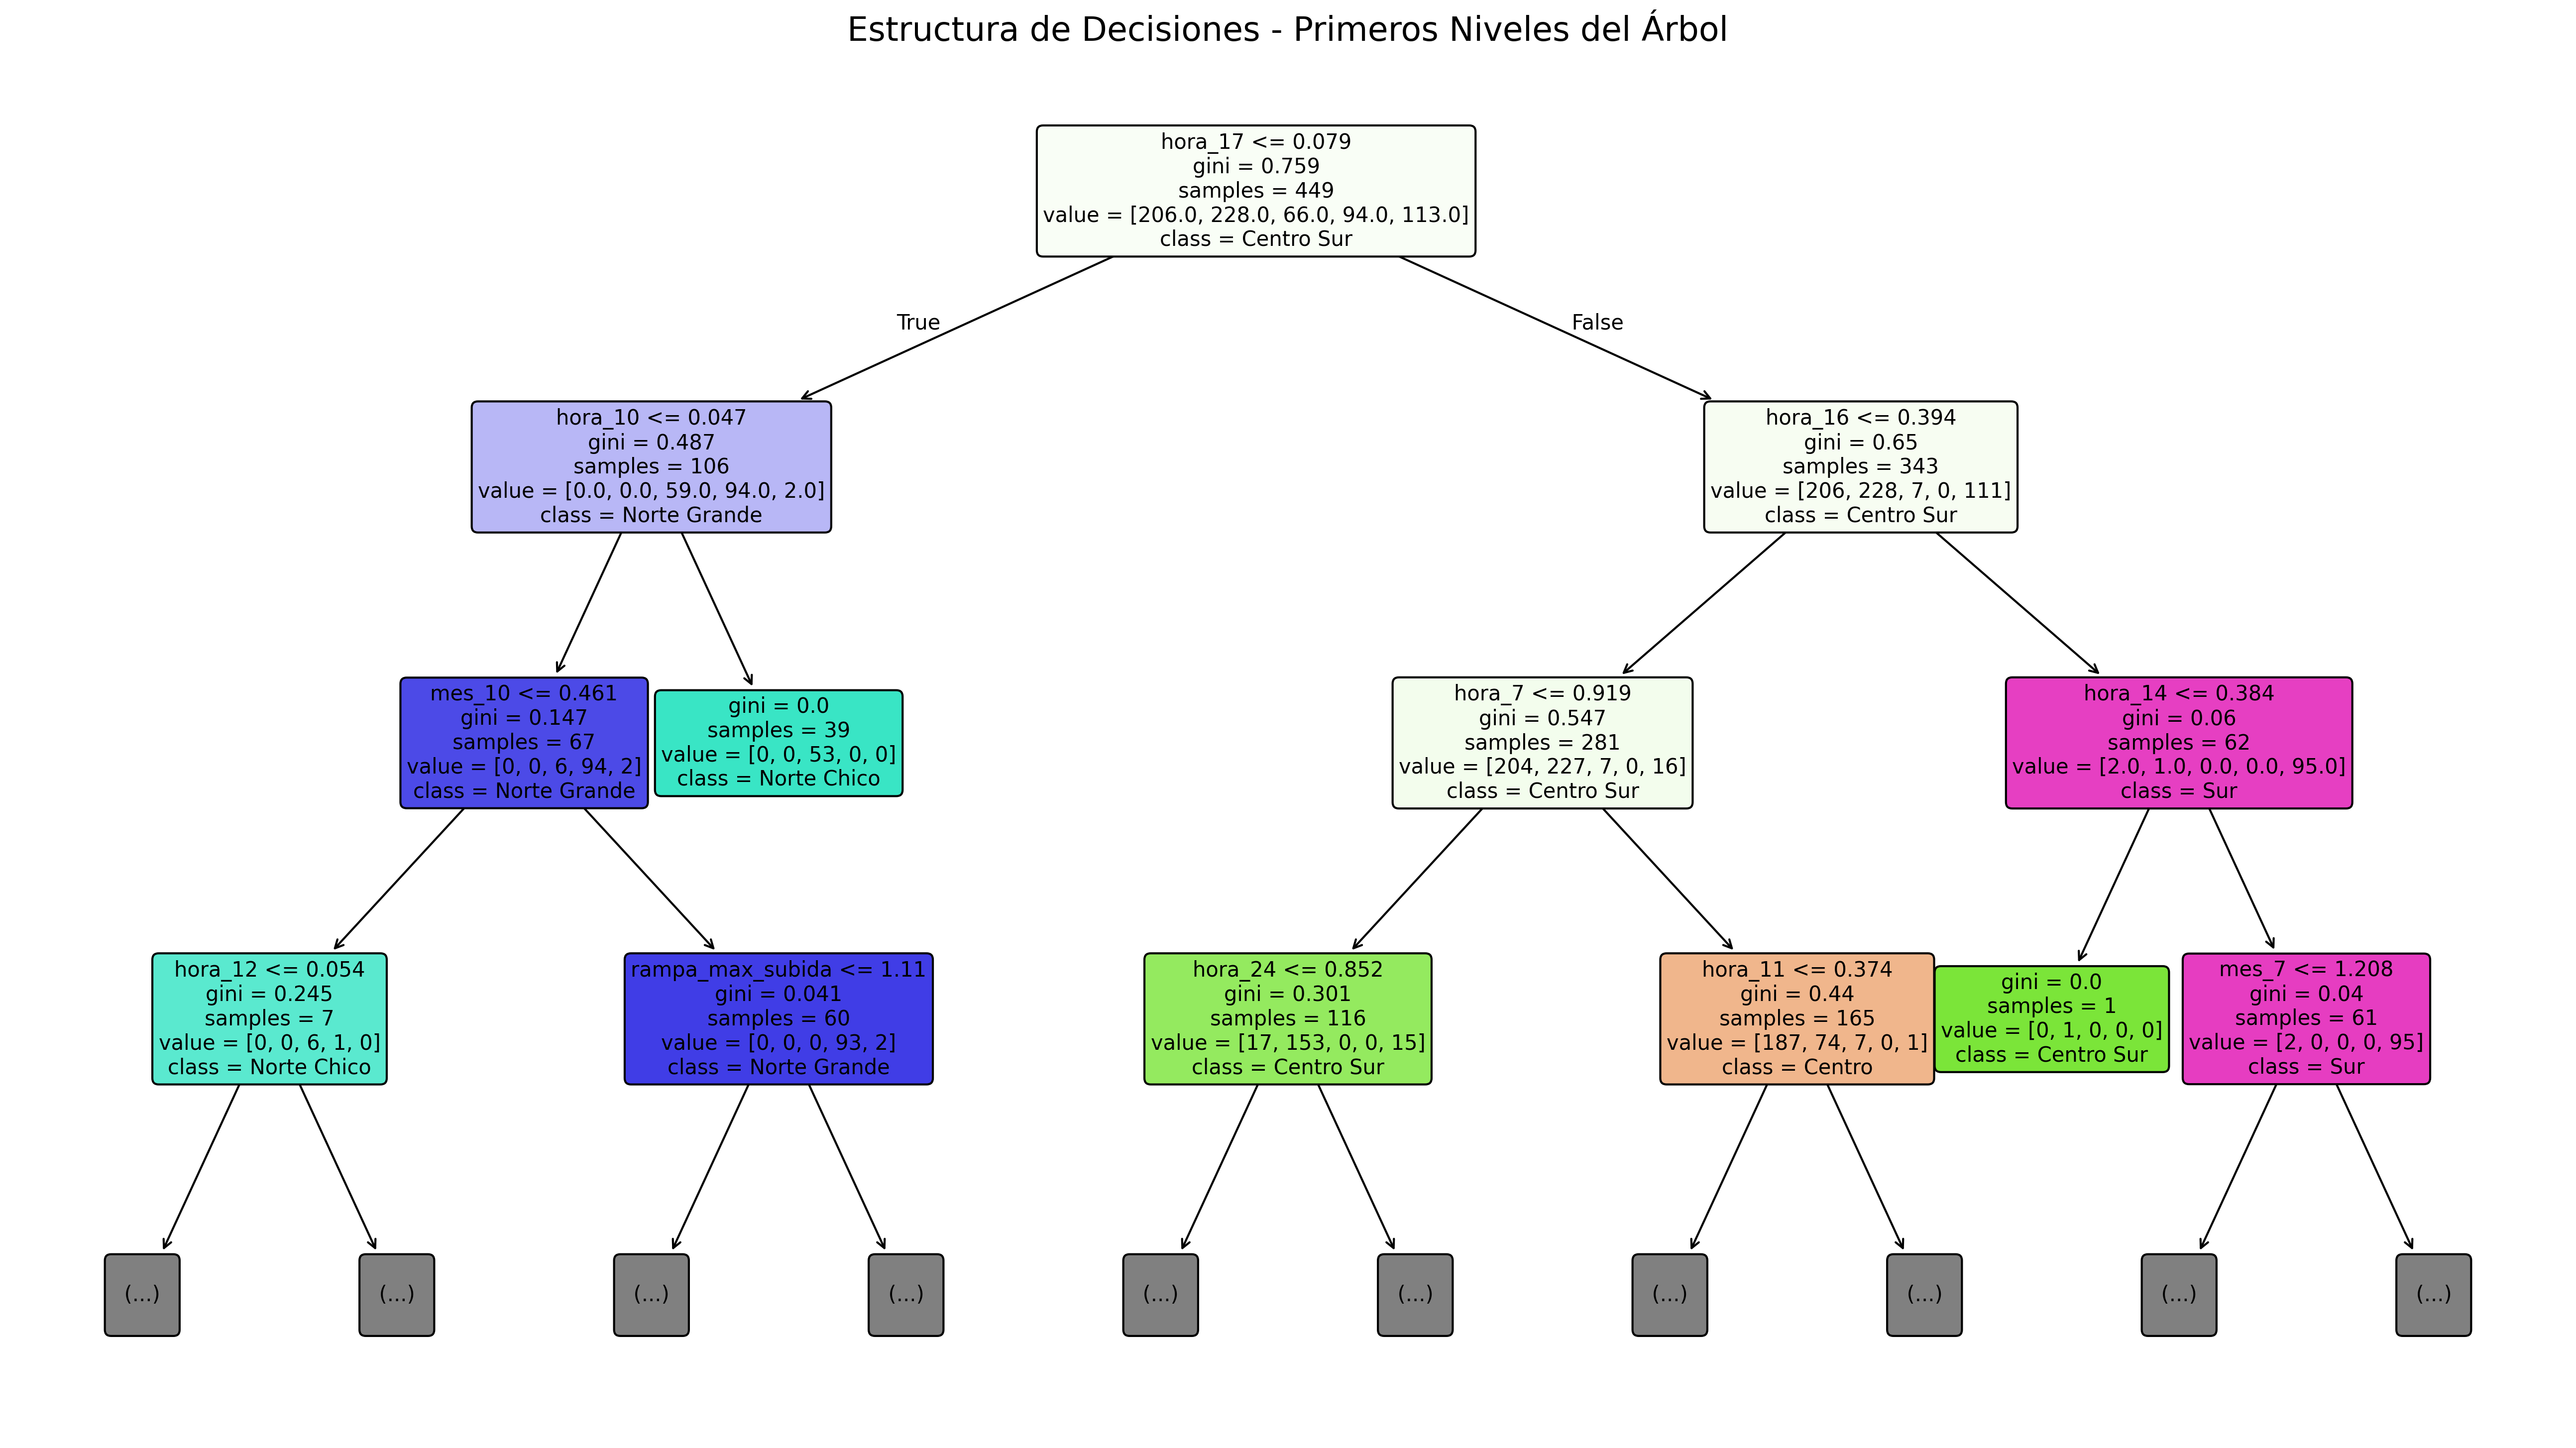

--- REGLAS LÓGICAS EN TEXTO (Primeros niveles) ---
|--- hora_17 <= 0.08
|   |--- hora_10 <= 0.05
|   |   |--- mes_10 <= 0.46
|   |   |   |--- hora_12 <= 0.05
|   |   |   |   |--- class: 3.0
|   |   |   |--- hora_12 >  0.05
|   |   |   |   |--- class: 2.0
|   |   |--- mes_10 >  0.46
|   |   |   |--- rampa_max_subida <= 1.11
|   |   |   |   |--- class: 3.0
|   |   |   |--- rampa_max_subida >  1.11
|   |   |   |   |--- truncated branch of depth 2
|   |--- hora_10 >  0.05
|   |   |--- class: 2.0
|--- hora_17 >  0.08
|   |--- hora_16 <= 0.39
|   |   |--- hora_7 <= 0.92
|   |   |   |--- hora_24 <= 0.85
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- hora_24 >  0.85
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- hora_7 >  0.92
|   |   |   |--- hora_11 <= 0.37
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- hora_11 >  0.37
|   |   |   |   |--- truncated branch of depth 5
|   |--- hora_16 >  0.39
|   |   |--- hora_14 <= 0.38
|   |   |   |--- cl

In [ ]:
un_arbol = rf_model.estimators_[0]

fig, ax = plt.subplots(figsize=(22, 12), dpi=300)

plot_tree(
    un_arbol,
    max_depth=3,  # Mostramos solo los primeros niveles para mantener la legibilidad
    feature_names=list(X_train_norm.columns),
    class_names=list(le.classes_),
    filled=True,  # Colorea los nodos según la macrozona predominante
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title("Estructura de Decisiones - Primeros Niveles del Árbol", fontsize=16)
plt.show()

--- REPORTE DE CLASIFICACIÓN: BASELINE (NAIVE BAYES) ---
              precision    recall  f1-score   support

      Centro       0.63      0.98      0.77        63
  Centro Sur       0.67      0.44      0.53        66
 Norte Chico       0.92      0.96      0.94        25
Norte Grande       0.97      0.97      0.97        34
         Sur       0.95      0.59      0.73        34

    accuracy                           0.76       222
   macro avg       0.83      0.79      0.79       222
weighted avg       0.78      0.76      0.74       222



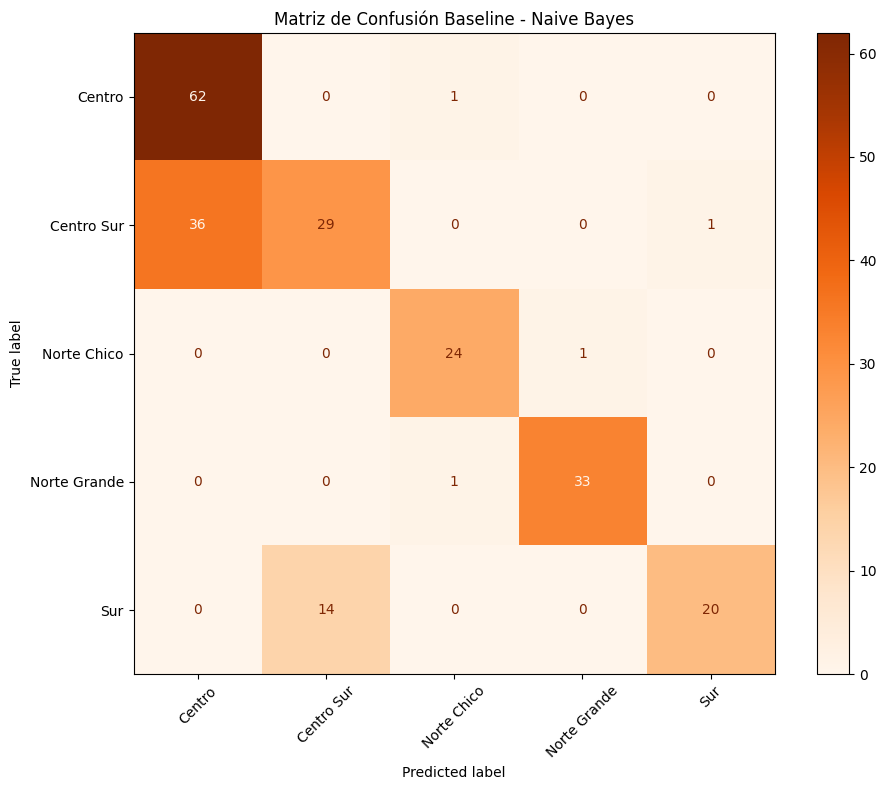

In [22]:
nb_model = GaussianNB()
nb_model.fit(X_train_norm, y_train)

y_pred_nb = nb_model.predict(X_test_norm)

print("--- REPORTE DE CLASIFICACIÓN: BASELINE (NAIVE BAYES) ---")
print(classification_report(y_test_num, y_pred_nb, target_names=le.classes_))

cm_nb = confusion_matrix(y_test_num, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_nb.plot(cmap='Oranges', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión Baseline - Naive Bayes")
plt.tight_layout()
plt.show()